# 03 - Modelado

Entrenamiento y comparacion de modelos de clasificacion para cada grupo de edad,
usando los datos ya preprocesados en el notebook 02.

**Cambios respecto a la version anterior de este notebook:**
1. Se anade `adolescents` a la lista de datasets (antes solo estaban adults,
   combined y toddlers).
2. El `scoring` de GridSearchCV cambia de `'f1'` a `'recall'`, porque en un
   contexto de cribado medico un falso negativo (no derivar a alguien que lo
   necesita) es mas grave que un falso positivo. El grid ahora busca los
   hiperparametros que maximizan recall, no F1.
3. Cada estimador se clona con `sklearn.base.clone()` dentro del bucle antes
   de entrenarlo, para evitar que las llamadas a `set_params()` (usadas para
   ajustar `scale_pos_weight` en XGBoost) dejen residuos de una iteracion a
   la siguiente si se reutiliza el mismo objeto Python entre datasets.


In [1]:
import pandas as pd
import pickle
import os
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay


In [2]:
os.makedirs('../models', exist_ok=True)

# CAMBIO: se anade "adolescents" a la lista de datasets. Antes solo se
# entrenaba con adults, combined y toddlers, dejando fuera uno de los
# cuatro grupos de edad que ya estan preprocesados desde el notebook 02.
datasets = ['adults', 'combined', 'toddlers', 'adolescents']

data_dict = {}

for name in datasets:
    # Cargar datos
    X_train = pd.read_csv(f'../data/processed/{name}_train.csv')
    X_test = pd.read_csv(f'../data/processed/{name}_test.csv')

    # Si tus archivos train/test ya contienen la variable target,
    # recuerda separarla (ej: y_train = X_train.pop('target_column'))

    data_dict[name] = {'train': X_train, 'test': X_test}

for name, data in data_dict.items():
    print(f"{name}: train={data['train'].shape}, test={data['test'].shape}")


adults: train=(563, 59), test=(141, 59)
combined: train=(4860, 18), test=(1215, 18)
toddlers: train=(843, 34), test=(211, 34)
adolescents: train=(83, 33), test=(21, 33)


In [3]:
RANDOM_STATE = 42
MODEL_SPACE = {
    "Baseline": {
        "estimator": DummyClassifier(strategy="most_frequent"),
        "param_grid": {}
    },
    "Regresion Logistica": {
        "estimator": LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=RANDOM_STATE
        ),
        "param_grid": {
            "C": [0.01, 0.1, 1, 10],
            #"penalty": ["l2"]
        }
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),
        "param_grid": {
            "n_estimators": [100, 200, 300],
            "max_depth": [None, 5, 10],
            "min_samples_leaf": [1, 2, 4]
        }
    },
    "XGBoost": {
        "estimator": XGBClassifier(
            eval_metric="logloss",
            random_state=RANDOM_STATE
        ),
        "param_grid": {
            "n_estimators": [100, 200],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.1, 0.2],
            # XGBoost no tiene class_weight; se usa scale_pos_weight para
            # compensar el desbalance. Se calcula por dataset mas abajo.
        }
    }
}


In [ ]:

# Configuracion de validacion cruzada

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)



all_results = []
# Bucle de entrenamiento
for name, data in data_dict.items():
    print(f"--- Entrenando para dataset: {name} ---")

    # Aqui accedes a la parte 'train' de tu diccionario
    df_train = data['train']



    # Suponiendo que el target es la ultima columna o tiene un nombre especifico
    # Si el target NO esta separado, separalo aqui:
    y_train = df_train.pop('target').astype(int) # Asegurate de que 'target' es el nombre real
    X_train = df_train

    # Calcular scale_pos_weight dinamicamente para XGBoost si hay desbalance
    ratio = (len(y_train) - y_train.sum()) / y_train.sum()

    for model_name, config in MODEL_SPACE.items():

        # CAMBIO: se clona el estimador en cada iteracion en vez de reutilizar
        # el mismo objeto Python guardado en MODEL_SPACE. Sin esto, la llamada
        # a set_params(scale_pos_weight=...) de mas abajo (para XGBoost) podria
        # dejar residuos de un dataset en el siguiente, ya que MODEL_SPACE se
        # crea una unica vez fuera del bucle y se recorre para los 4 datasets.
        clf = clone(config['estimator'])
        params = config['param_grid']

        # Ajuste especial para XGBoost si es necesario
        if model_name == "XGBoost":
            clf.set_params(scale_pos_weight=ratio)

        # CAMBIO: scoring cambia de 'f1' a 'recall'. En cribado medico, un
        # falso negativo (no derivar a alguien que lo necesita) es mas grave
        # que un falso positivo, asi que el grid debe buscar los hiperparametros
        # que maximizan recall, no el equilibrio precision/recall que da F1.
        grid = GridSearchCV(clf, params, cv=cv, scoring='recall')
        grid.fit(X_train, y_train)

        y_pred = grid.best_estimator_.predict(data['test'].drop('target', axis=1))
        y_test = data['test']['target']

        print(f"Resultados para {name} - {model_name}:")
        print(classification_report(y_test, y_pred, zero_division=0))
        print("Matriz de Confusion:")
        print(confusion_matrix(y_test, y_pred))

        # Modifica tu bloque de append asi:
        report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

        # Capturamos las metricas especificas de la clase '1' (TEA)
        # y las metricas globales
        all_results.append({
            'Dataset': name,
            'Modelo': model_name,
            'F1-Score (TEA)': report['1']['f1-score'],
            'Recall (TEA)': report['1']['recall'],
            'Precision (TEA)': report['1']['precision'],
            'Accuracy Global': report['accuracy'],
            'Support (TEA)': report['1']['support']
        })

        # 2. Guardar el mejor modelo
        model_filename = f'../models/{name}_{model_name}.pkl'
        with open(model_filename, 'wb') as f:
            pickle.dump(grid.best_estimator_, f)

        print(f"Modelo {model_name} guardado en {model_filename}")


--- Entrenando para dataset: adults ---
Resultados para adults - Baseline:
              precision    recall  f1-score   support

           0       0.73      1.00      0.84       103
           1       0.00      0.00      0.00        38

    accuracy                           0.73       141
   macro avg       0.37      0.50      0.42       141
weighted avg       0.53      0.73      0.62       141

Matriz de Confusion:
[[103   0]
 [ 38   0]]
Modelo Baseline guardado en ../models/adults_Baseline.pkl
Resultados para adults - Regresion Logistica:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       103
           1       0.95      0.97      0.96        38

    accuracy                           0.98       141
   macro avg       0.97      0.98      0.97       141
weighted avg       0.98      0.98      0.98       141

Matriz de Confusion:
[[101   2]
 [  1  37]]
Modelo Regresion Logistica guardado en ../models/adults_Regresion Logistica.pkl

In [ ]:
df_resumen = pd.DataFrame(all_results)
df_resumen


,Dataset,Modelo,F1-Score (TEA),Recall (TEA),Precision (TEA),Accuracy Global,Support (TEA)
0,adults,Baseline,0.000000,0.000000,0.000000,0.730496,38.0
1,adults,Regresion Logistica,0.961039,0.973684,0.948718,0.978723,38.0
2,adults,Random Forest,0.909091,0.921053,0.897436,0.950355,38.0
3,adults,XGBoost,0.973684,0.973684,0.973684,0.985816,38.0
4,combined,Baseline,0.000000,0.000000,0.000000,0.702881,361.0
5,combined,Regresion Logistica,0.861009,0.969529,0.774336,0.906996,361.0
6,combined,Random Forest,0.896287,0.969529,0.833333,0.933333,361.0
7,combined,XGBoost,0.990398,1.000000,0.980978,0.994239,361.0
8,toddlers,Baseline,0.817927,1.000000,0.691943,0.691943,146.0
9,toddlers,Regresion Logistica,1.000000,1.000000,1.000000,1.000000,146.0


### Mejor modelo por dataset segun recall

Se anade este bloque para identificar explicitamente, por cada grupo de
edad, cual es el modelo con mejor recall en el test. Antes solo se veia
mirando la tabla completa a mano.


In [ ]:
mejores_por_dataset = (
    df_resumen[df_resumen["Modelo"] != "Baseline"]
    .sort_values(["Recall (TEA)", "F1-Score (TEA)"], ascending=False)
    .groupby("Dataset")
    .head(1)
    .sort_values("Dataset")
)
print("Mejor modelo por dataset (Recall como criterio principal, F1 como desempate):")
print(mejores_por_dataset[["Dataset", "Modelo", "Recall (TEA)", "F1-Score (TEA)", "Precision (TEA)"]].to_string(index=False))


Mejor modelo por dataset (Recall como criterio principal, F1 como desempate):
    Dataset              Modelo  Recall (TEA)  F1-Score (TEA)  Precision (TEA)
adolescents Regresion Logistica      1.000000        1.000000         1.000000
     adults             XGBoost      0.973684        0.973684         0.973684
   combined             XGBoost      1.000000        0.990398         0.980978
   toddlers Regresion Logistica      1.000000        1.000000         1.000000


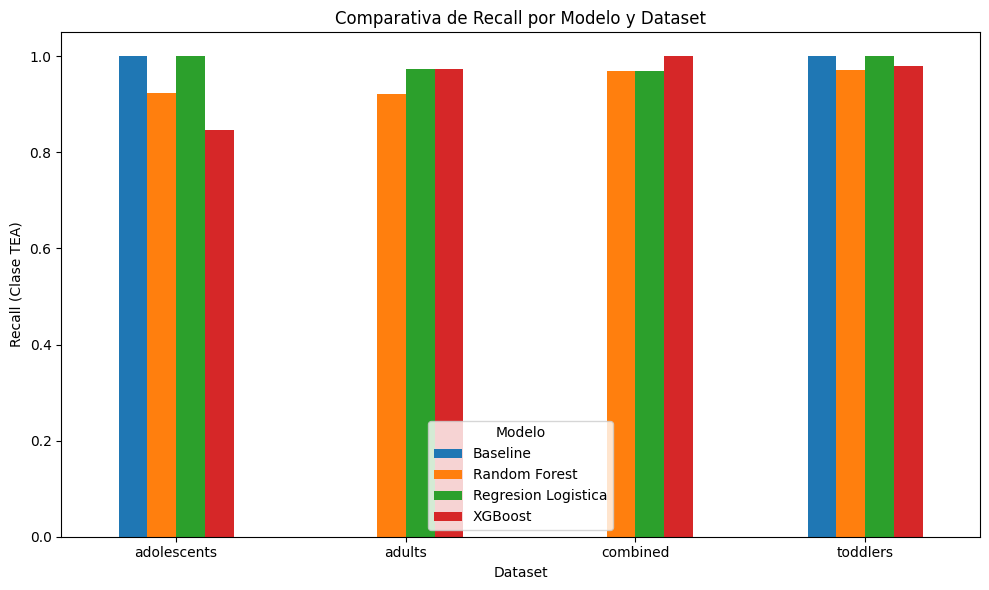

In [ ]:

import matplotlib.pyplot as plt

# Esto hara que el desempeno de los modelos sea evidente a simple vista
df_resumen.pivot(index='Dataset', columns='Modelo', values='Recall (TEA)').plot(kind='bar', figsize=(10, 6))
plt.title("Comparativa de Recall por Modelo y Dataset")
plt.ylabel("Recall (Clase TEA)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../docs/assets/img/comparativa_recall.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
import pickle  # Asegurate de importar pickle

# Cargar el modelo guardado con pickle
model_path = '../models/adults_XGBoost.pkl'
with open(model_path, 'rb') as f:
    modelo_cargado = pickle.load(f)

# 1. Obtenemos el DataFrame de test
df_test = data_dict["adults"]["test"].copy()

# 2. Eliminamos el target para que coincida con las columnas del entrenamiento
if 'target' in df_test.columns:
    y_test_check = df_test['target']
    df_test = df_test.drop(columns=['target'])
else:
    y_test_check = None

# 3. Prediccion de ejemplo sobre el primer registro de test
prediccion = modelo_cargado.predict(df_test.iloc[[0]])[0]
print("Prediccion del modelo:", prediccion)
if y_test_check is not None:
    print("Valor real (etiqueta):", y_test_check.iloc[0])
    print("¡El modelo ha acertado!" if prediccion == y_test_check.iloc[0] else "El modelo ha fallado en este caso concreto.")


Prediccion del modelo: 0
Valor real (etiqueta): 0
¡El modelo ha acertado!
